# 02 · Exploratory Data Analysis

**Goal:** describe how the business performs, covering sales trend, timing, categories,
customers, geography and delivery, and test the relationships that matter for the later modules.

All figures are read from the `analytics` views in PostgreSQL (`sql/views.sql`), the same layer the
API and dashboard use. **Profit and margin are estimates** based on the synthetic cost model
(`docs/architecture.md`). Every other metric is real Olist data.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))   # project root, for data_pipeline

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from IPython.display import Markdown, display

from nexus_nb import AXIS, GRID, INK, MUTED_FILL, SEQUENTIAL_BLUE, SERIES, brl, query

from scipy import stats

period = query("SELECT * FROM analytics.v_reporting_period").iloc[0]
period.to_frame("value")

,value
data_start,2017-01-14
data_end,2018-08-23
first_month,2017-02-01
last_month,2018-07-01
reference_date,2018-08-24


## 1. Revenue over time

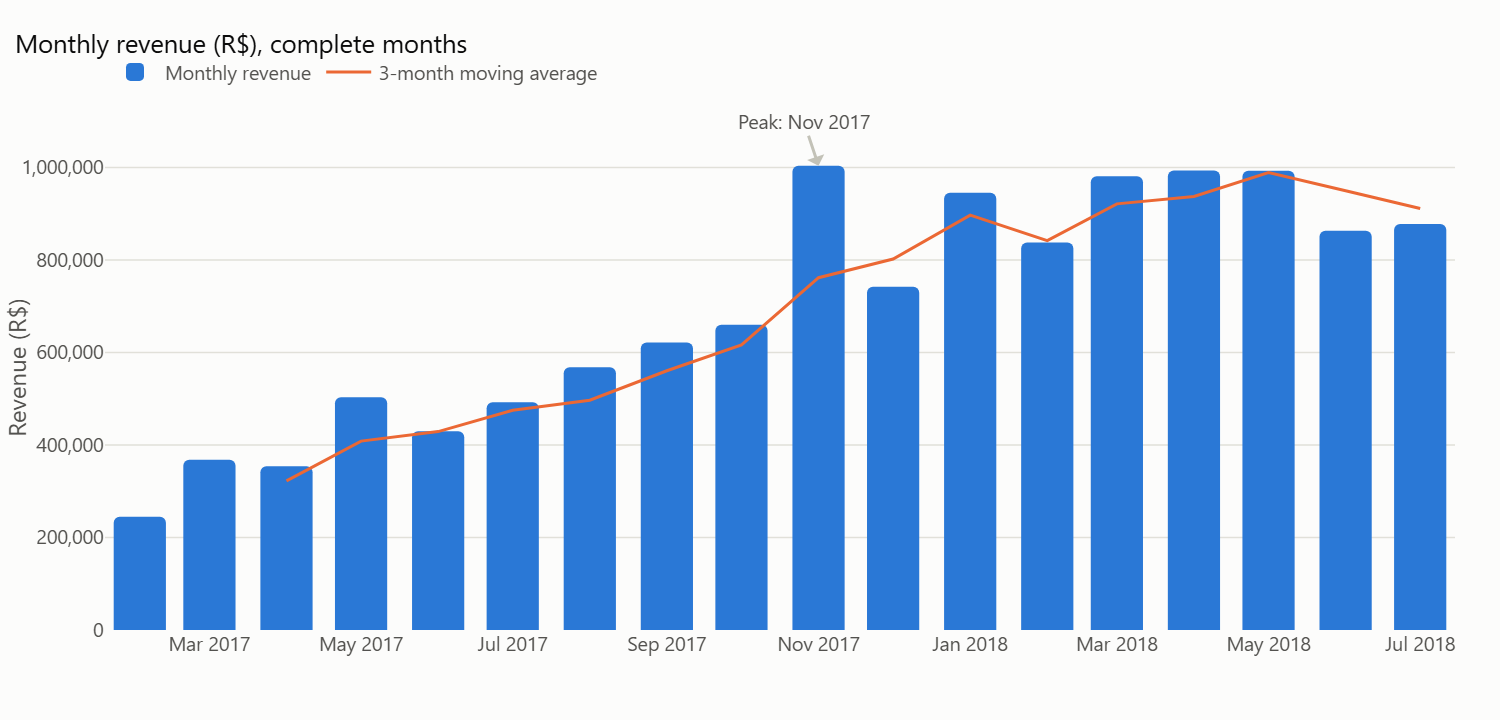

,month,revenue,orders,avg_order_value,new_customers,revenue_growth_mom,revenue_growth_yoy
10,2017-12-01,"742,183.79",5620,132.06,5439,-0.26,NaN
11,2018-01-01,"945,456.29",7187,131.55,6951,0.27,NaN
12,2018-02-01,"837,895.43",6625,126.47,6357,-0.11,2.42
13,2018-03-01,"981,051.06",7168,136.87,6931,0.17,1.66
14,2018-04-01,"993,592.98",6919,143.60,6698,0.01,1.81
15,2018-05-01,"992,871.75",6833,145.31,6586,-0.00,0.97
16,2018-06-01,"863,265.53",6145,140.48,5920,-0.13,1.01
17,2018-07-01,"878,044.27",6233,140.87,6016,0.02,0.78


In [2]:
monthly = query("SELECT * FROM analytics.v_monthly_kpis WHERE is_complete ORDER BY month")
monthly["revenue_3m_avg"] = monthly["revenue"].rolling(3).mean()
peak = monthly.loc[monthly["revenue"].idxmax()]

fig = go.Figure()
fig.add_bar(x=monthly["month"], y=monthly["revenue"], name="Monthly revenue", marker_color=SERIES[0],
            hovertemplate="%{x|%b %Y}: R$ %{y:,.0f}<extra></extra>")
fig.add_scatter(x=monthly["month"], y=monthly["revenue_3m_avg"], name="3-month moving average", mode="lines",
                line=dict(color=SERIES[1], width=2), hovertemplate="%{x|%b %Y}: R$ %{y:,.0f}<extra></extra>")
fig.add_annotation(x=peak["month"], y=peak["revenue"], text=f"Peak: {peak['month']:%b %Y}", showarrow=True,
                   arrowcolor=AXIS, ay=-30, font=dict(color=INK["secondary"]))
fig.update_layout(title="Monthly revenue (R$), complete months", yaxis=dict(title="Revenue (R$)", tickformat=",.0f"))
fig.show()

monthly[["month", "revenue", "orders", "avg_order_value", "new_customers", "revenue_growth_mom", "revenue_growth_yoy"]].tail(8)

### Last complete month vs the month before

This uses `analytics.kpi_summary()`, the same function that feeds the dashboard KPI cards.

In [3]:
kpis = query("""
    SELECT * FROM analytics.kpi_summary(
        (SELECT last_month FROM analytics.v_reporting_period),
        (SELECT (last_month + interval '1 month - 1 day')::date FROM analytics.v_reporting_period))
""")
kpis

,metric,current_value,previous_value,change_abs,change_pct
0,revenue,"878,044.27","863,265.53","14,778.74",1.71
1,estimated_profit,"339,816.37","336,404.72","3,411.65",1.01
2,estimated_margin,0.39,0.39,-0.00,-0.69
3,orders,"6,233.00","6,145.00",88.00,1.43
4,customers,"6,172.00","6,106.00",66.00,1.08
5,avg_order_value,140.87,140.48,0.39,0.28


## 2. When do customers buy?

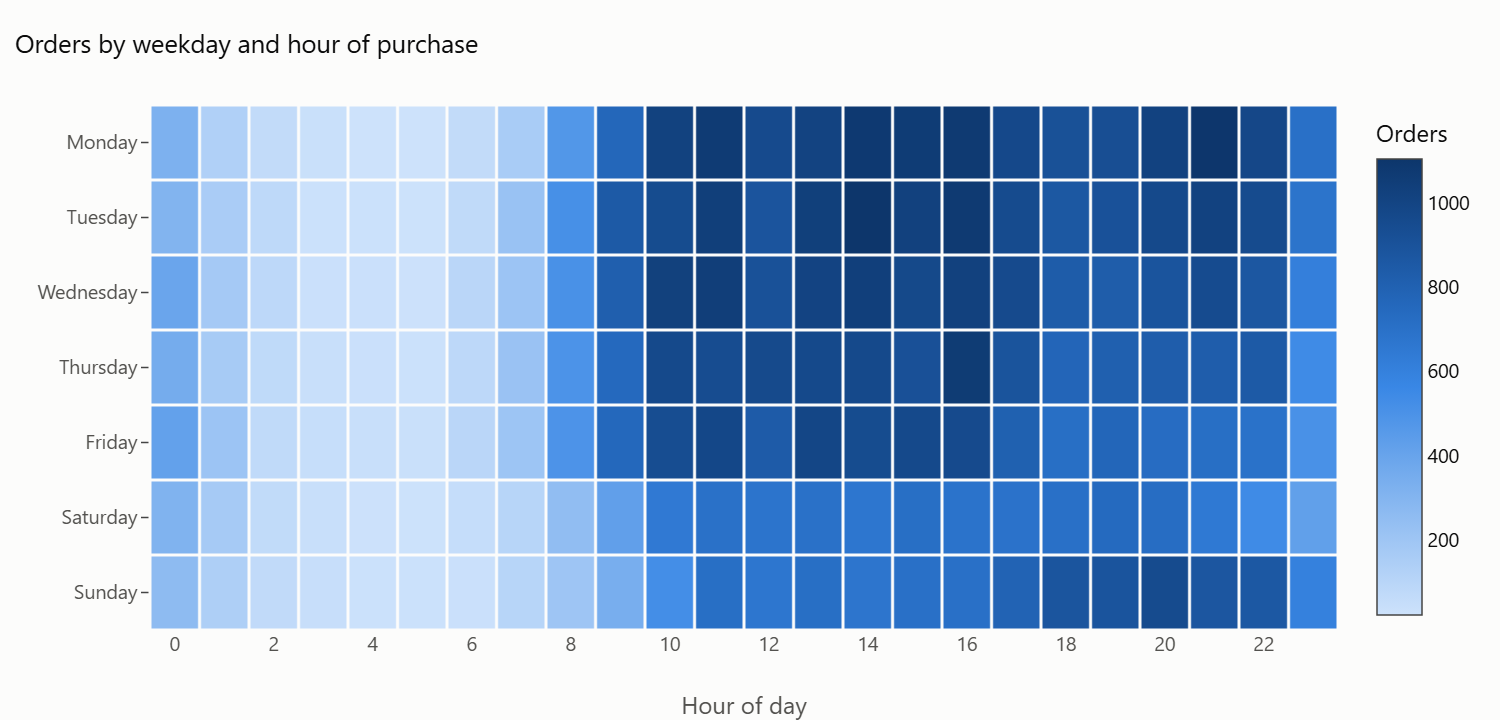

In [4]:
wh = query("""
    SELECT c.day_of_week, c.day_name, extract(hour FROM o.purchased_at)::int AS hour, count(*) AS orders
    FROM analytics.v_orders o
    JOIN core.calendar c ON c.date_key = o.purchase_date
    WHERE o.is_valid_sale
    GROUP BY 1, 2, 3
""")
grid = wh.pivot_table(index=["day_of_week", "day_name"], columns="hour", values="orders").droplevel(0)

fig = go.Figure(go.Heatmap(z=grid.values, x=grid.columns, y=grid.index, colorscale=SEQUENTIAL_BLUE,
                           xgap=2, ygap=2, colorbar=dict(title="Orders"),
                           hovertemplate="%{y} %{x}:00 · %{z:,} orders<extra></extra>"))
fig.update_layout(title="Orders by weekday and hour of purchase", xaxis=dict(title="Hour of day", dtick=2),
                  yaxis=dict(autorange="reversed", showgrid=False), height=420, margin=dict(l=100))
fig.show()

by_day = wh.groupby("day_name")["orders"].sum().sort_values(ascending=False)
by_hour = wh.groupby("hour")["orders"].sum()

## 3. Categories

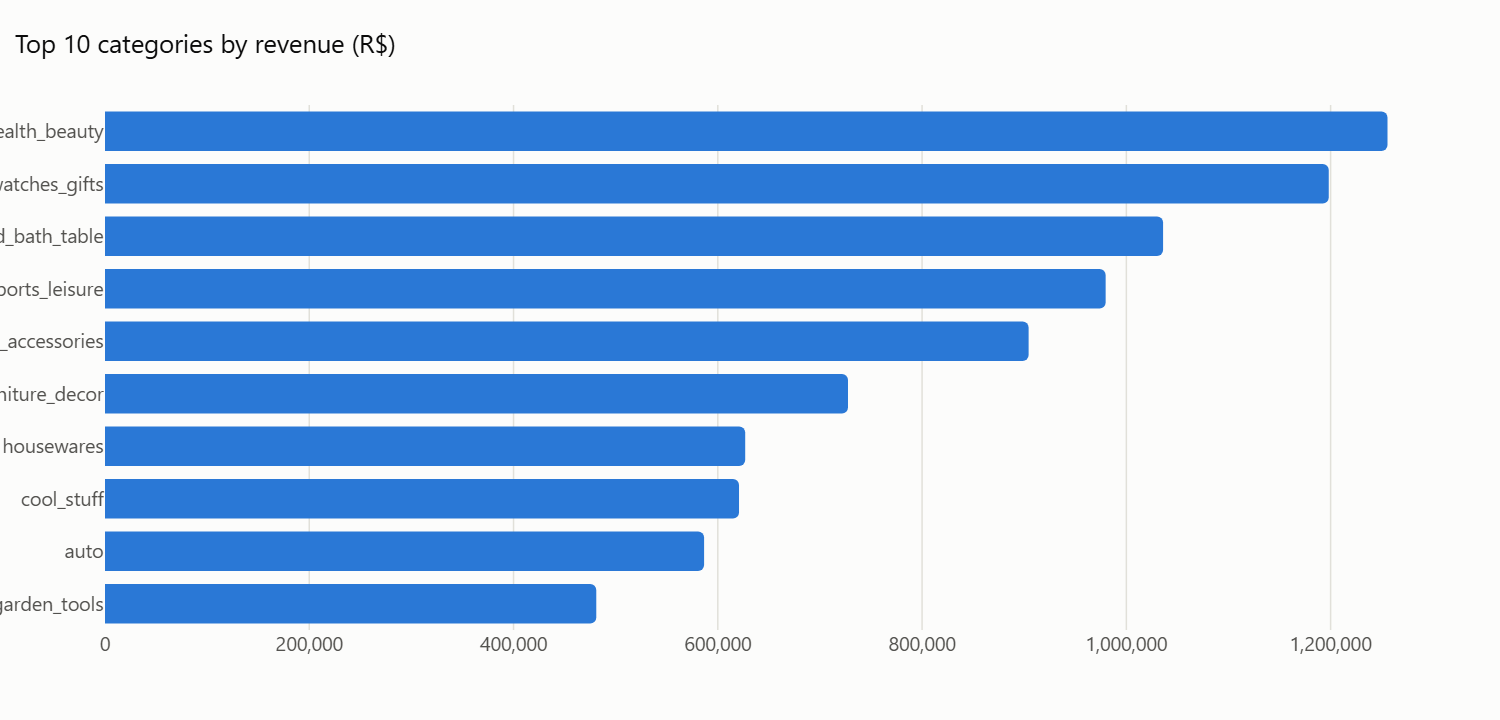

,category,revenue,revenue_share,orders,revenue_prev_3m,revenue_last_3m,growth_3m
0,health_beauty,"1,255,695.13",0.09,8800,"268,072.26","309,264.35",0.15
1,watches_gifts,"1,198,185.21",0.09,5604,"253,505.84","306,970.81",0.21
2,bed_bath_table,"1,035,964.06",0.08,9399,"202,080.92","198,115.43",-0.02
3,sports_leisure,"979,740.92",0.07,7673,"227,309.68","160,313.91",-0.29
4,computers_accessories,"904,322.02",0.07,6654,"245,556.32","134,921.46",-0.45
5,furniture_decor,"727,465.05",0.05,6425,"147,264.31","141,905.66",-0.04
6,housewares,"626,825.80",0.05,5847,"118,073.39","182,126.44",0.54
7,cool_stuff,"620,770.49",0.05,3616,"104,165.84","70,707.29",-0.32
8,auto,"586,585.73",0.04,3872,"135,722.44","129,872.52",-0.04
9,garden_tools,"481,009.94",0.04,3505,"89,140.02","82,055.67",-0.08


In [5]:
cat = query("SELECT * FROM analytics.v_category_performance ORDER BY revenue DESC")
top = cat.head(10).iloc[::-1]

fig = go.Figure(go.Bar(x=top["revenue"], y=top["category"], orientation="h", marker_color=SERIES[0],
                       customdata=top["revenue_share"] * 100,
                       hovertemplate="%{y}: R$ %{x:,.0f} (%{customdata:.1f}% of revenue)<extra></extra>"))
fig.update_layout(title="Top 10 categories by revenue (R$)", xaxis=dict(tickformat=",.0f", showgrid=True, gridcolor=GRID),
                  yaxis=dict(showgrid=False), height=460)
fig.show()

top10_share = cat.head(10)["revenue_share"].sum()
cat.head(10)[["category", "revenue", "revenue_share", "orders", "revenue_prev_3m", "revenue_last_3m", "growth_3m"]]

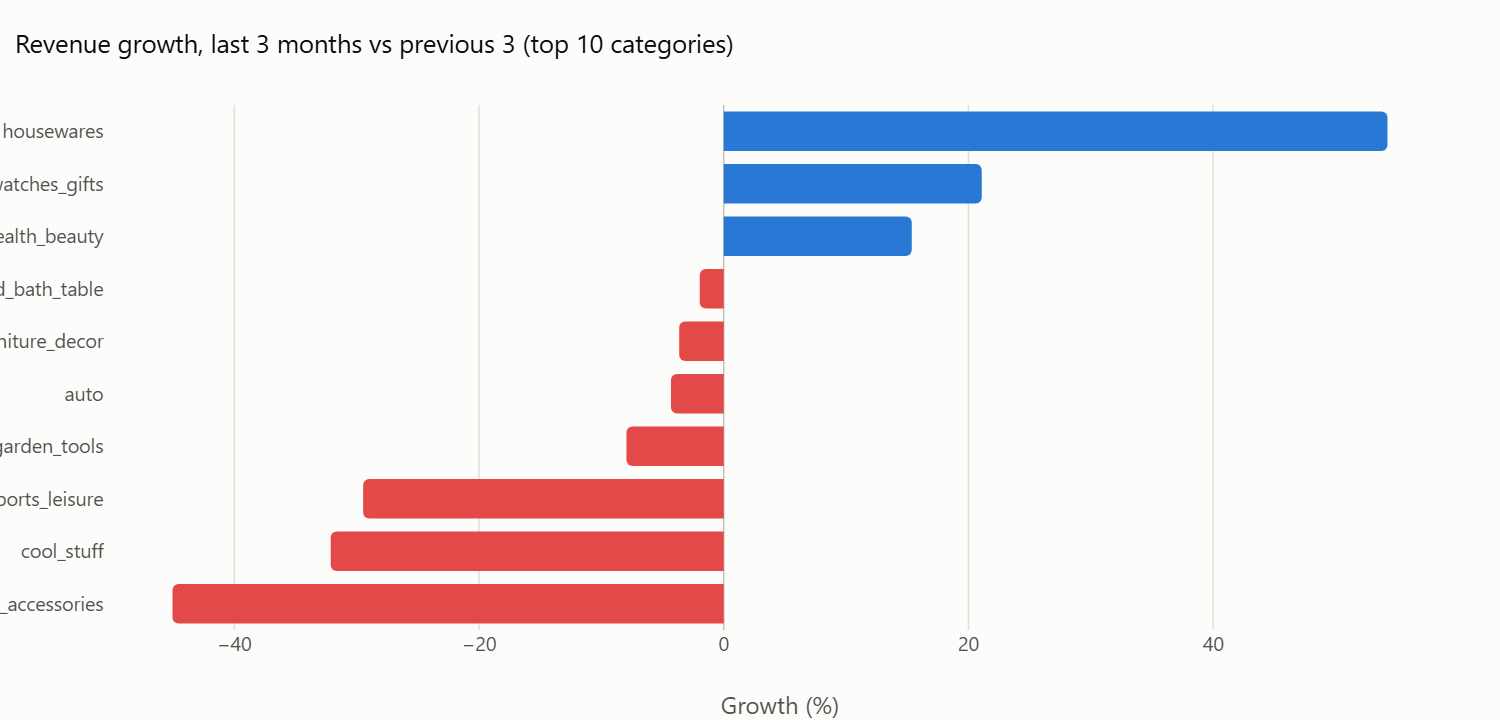

In [6]:
# Momentum: last 3 complete months vs the 3 before, for the 10 largest categories.
mom = cat.head(10).sort_values("growth_3m")
colors = [SERIES[0] if g >= 0 else SERIES[7] for g in mom["growth_3m"]]
fig = go.Figure(go.Bar(x=mom["growth_3m"] * 100, y=mom["category"], orientation="h", marker_color=colors,
                       hovertemplate="%{y}: %{x:+.1f}%<extra></extra>"))
fig.update_layout(title="Revenue growth, last 3 months vs previous 3 (top 10 categories)",
                  xaxis=dict(title="Growth (%)", zeroline=True, zerolinecolor=AXIS, showgrid=True, gridcolor=GRID),
                  yaxis=dict(showgrid=False), height=460)
fig.show()

## 4. Revenue concentration (Pareto)

How much of the catalogue drives most of the revenue?

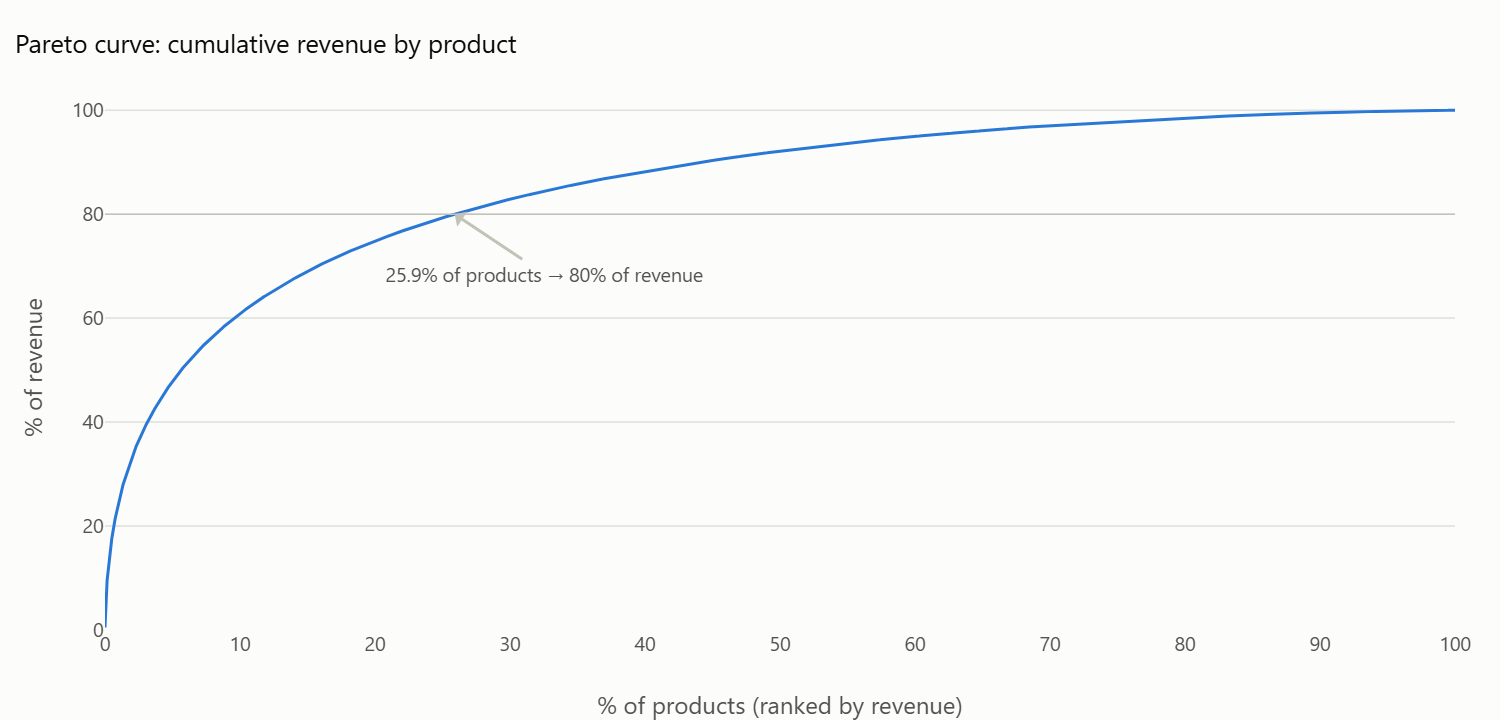

In [7]:
prod = query("SELECT revenue FROM analytics.v_product_performance ORDER BY revenue DESC")
cum_share = prod["revenue"].cumsum() / prod["revenue"].sum()
catalogue_share = np.arange(1, len(prod) + 1) / len(prod)
k80 = int((cum_share < 0.80).sum()) + 1

fig = go.Figure(go.Scatter(x=catalogue_share * 100, y=cum_share * 100, mode="lines", line=dict(color=SERIES[0], width=2),
                           name="Cumulative revenue", hovertemplate="Top %{x:.1f}% of products → %{y:.1f}% of revenue<extra></extra>"))
fig.add_hline(y=80, line=dict(color=AXIS, width=1))
fig.add_annotation(x=k80 / len(prod) * 100, y=80, text=f"{k80 / len(prod):.1%} of products → 80% of revenue",
                   showarrow=True, arrowcolor=AXIS, ax=60, ay=40, font=dict(color=INK["secondary"]))
fig.update_layout(title="Pareto curve: cumulative revenue by product", xaxis=dict(title="% of products (ranked by revenue)"),
                  yaxis=dict(title="% of revenue", range=[0, 101]))
fig.show()

## 5. Customers: how many come back?

In [8]:
cust = query("SELECT orders, total_revenue, is_repeat_customer, avg_days_between_orders FROM analytics.v_customer_summary")
repeat_rate = cust["is_repeat_customer"].mean()
repeat_revenue_share = cust.loc[cust["is_repeat_customer"], "total_revenue"].sum() / cust["total_revenue"].sum()
aov_one = cust.loc[~cust["is_repeat_customer"], "total_revenue"].mean()
clv_repeat = cust.loc[cust["is_repeat_customer"], "total_revenue"].mean()
pd.Series({
    "customers": len(cust),
    "repeat customers": int(cust["is_repeat_customer"].sum()),
    "repeat rate": repeat_rate,
    "revenue share of repeat customers": repeat_revenue_share,
    "avg lifetime revenue, one-time buyers (R$)": aov_one,
    "avg lifetime revenue, repeat buyers (R$)": clv_repeat,
}).to_frame("value")

,value
customers,"94,651.00"
repeat customers,"2,873.00"
repeat rate,0.03
revenue share of repeat customers,0.06
"avg lifetime revenue, one-time buyers (R$)",138.46
"avg lifetime revenue, repeat buyers (R$)",260.15


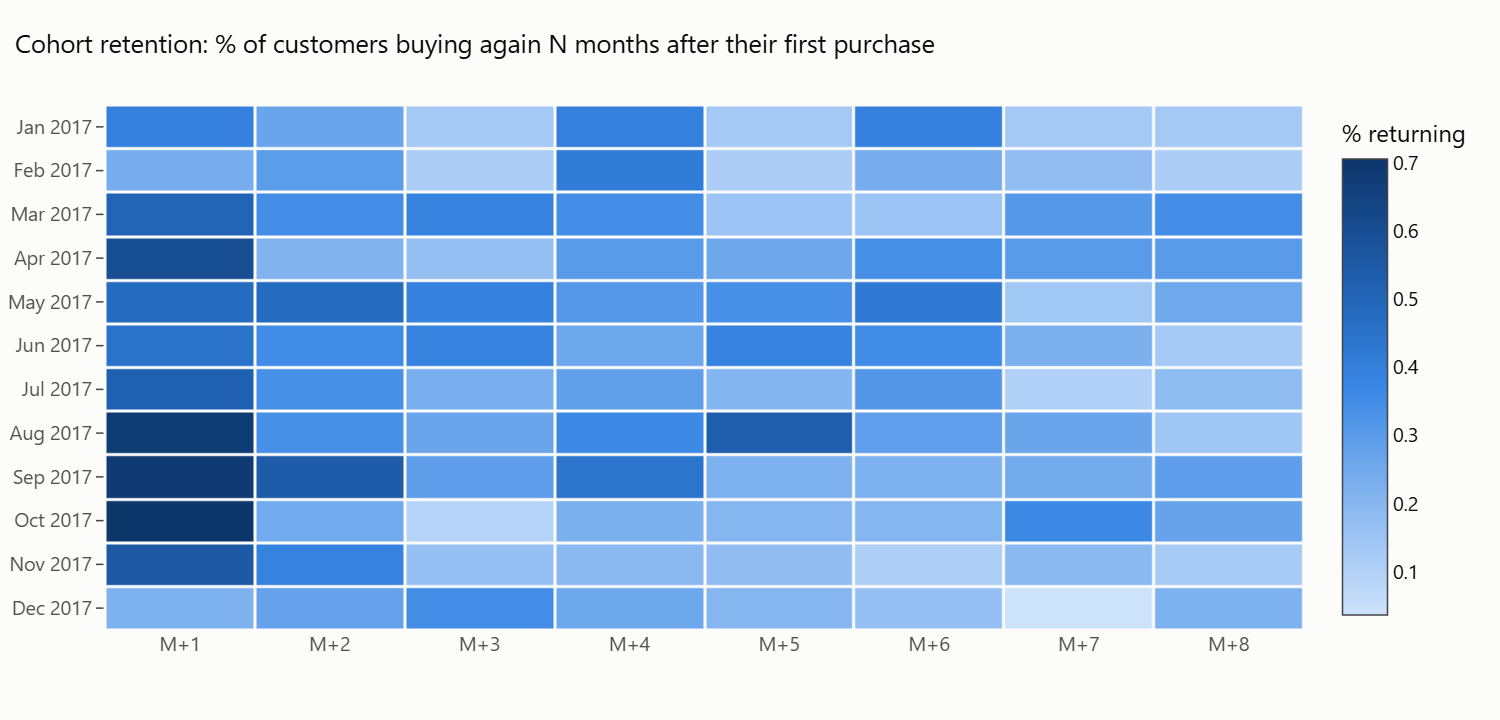

age,1,2,3,4,5,6,7,8
cohort,,,,,,,,
2017-01-01,0.40,0.27,0.13,0.40,0.13,0.40,0.13,0.13
2017-02-01,0.24,0.30,0.12,0.41,0.12,0.24,0.18,0.12
2017-03-01,0.51,0.35,0.39,0.35,0.16,0.16,0.31,0.35
2017-04-01,0.60,0.22,0.17,0.30,0.26,0.34,0.30,0.30
2017-05-01,0.48,0.48,0.40,0.31,0.34,0.42,0.14,0.25
2017-06-01,0.45,0.35,0.39,0.26,0.39,0.35,0.23,0.13
2017-07-01,0.52,0.34,0.24,0.29,0.21,0.31,0.10,0.18
2017-08-01,0.68,0.34,0.27,0.36,0.53,0.29,0.27,0.15
2017-09-01,0.69,0.54,0.29,0.44,0.22,0.22,0.25,0.29


In [9]:
# Monthly cohort retention: % of each first-purchase cohort that buys again N months later.
orders = query("SELECT customer_key, order_month FROM analytics.v_orders WHERE is_valid_sale")
orders["order_month"] = pd.to_datetime(orders["order_month"])
orders["cohort"] = orders.groupby("customer_key")["order_month"].transform("min")
orders["age"] = ((orders["order_month"].dt.year - orders["cohort"].dt.year) * 12
                 + (orders["order_month"].dt.month - orders["cohort"].dt.month))
cohorts = orders[(orders["cohort"] >= "2017-01-01") & (orders["cohort"] <= "2017-12-01")]
size = cohorts[cohorts["age"] == 0].groupby("cohort")["customer_key"].nunique()
active = cohorts[cohorts["age"].between(1, 8)].groupby(["cohort", "age"])["customer_key"].nunique().unstack()
retention = active.div(size, axis=0) * 100

fig = go.Figure(go.Heatmap(z=retention.values, x=[f"M+{a}" for a in retention.columns],
                           y=retention.index.strftime("%b %Y"), colorscale=SEQUENTIAL_BLUE, xgap=2, ygap=2,
                           colorbar=dict(title="% returning"), hovertemplate="%{y} cohort, %{x}: %{z:.2f}%<extra></extra>"))
fig.update_layout(title="Cohort retention: % of customers buying again N months after their first purchase",
                  yaxis=dict(autorange="reversed", showgrid=False), height=460)
fig.show()
retention.round(2)

In [10]:
gaps = query("""
    WITH p AS (
        SELECT purchased_at::date - lag(purchased_at::date) OVER (PARTITION BY customer_key ORDER BY purchased_at) AS gap
        FROM analytics.v_orders WHERE is_valid_sale)
    SELECT gap FROM p WHERE gap IS NOT NULL
""")["gap"]
gap_stats = gaps.describe(percentiles=[0.25, 0.5, 0.75, 0.9])
gap_stats["same_day_share"] = (gaps == 0).mean()
gap_stats.to_frame("days between consecutive purchases")

,days between consecutive purchases
count,"3,217.00"
mean,78.89
std,107.62
min,0.00
25%,0.00
50%,29.00
75%,121.00
90%,242.00
max,609.00
same_day_share,0.29


## 6. Geography

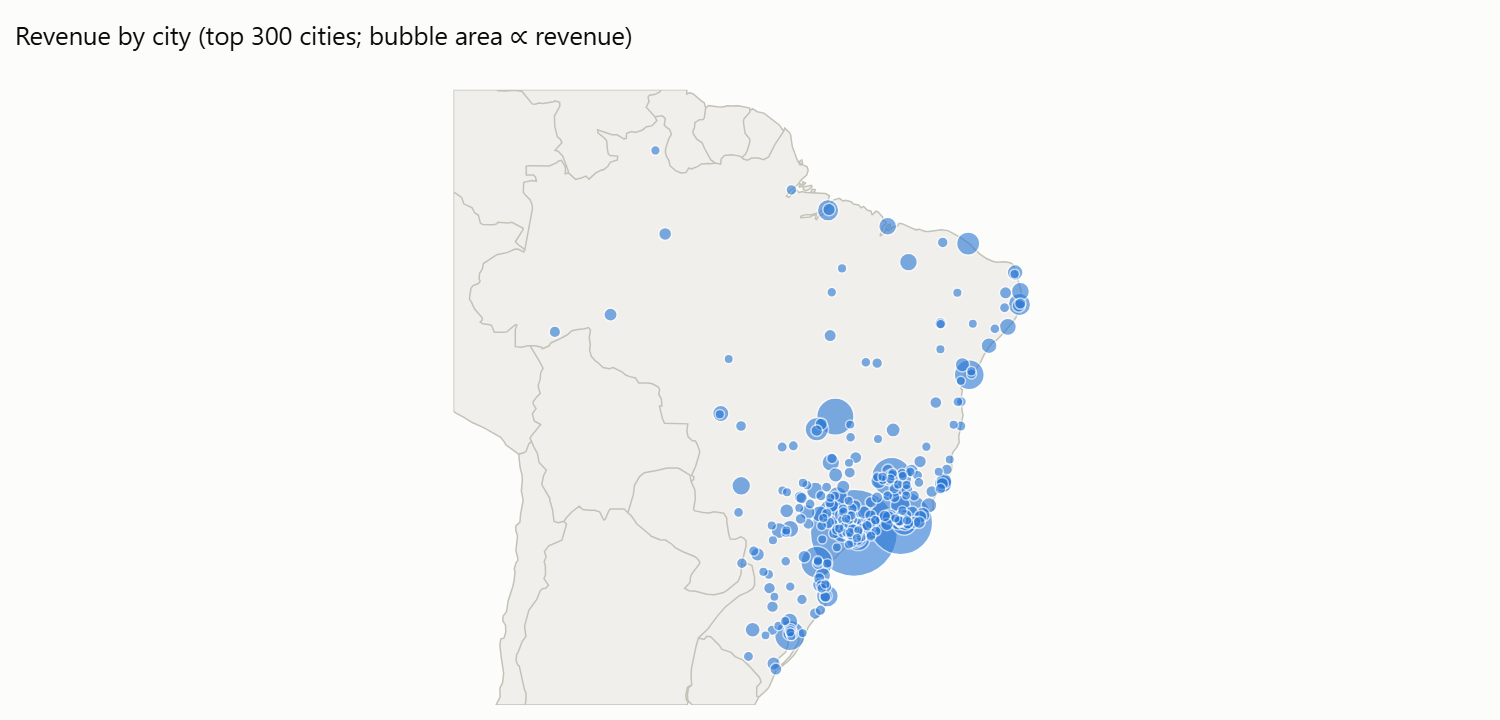

,state_code,state_name,region,revenue,revenue_share,customers,avg_delivery_days,late_delivery_rate,avg_review_score,growth_6m
0,SP,São Paulo,Sudeste,"5,163,867.22",0.38,39749,8.70,0.04,4.21,0.33
1,RJ,Rio de Janeiro,Sudeste,"1,811,623.42",0.13,12242,15.20,0.12,3.90,0.04
2,MG,Minas Gerais,Sudeste,"1,573,508.20",0.12,11134,11.90,0.05,4.16,0.16
3,RS,Rio Grande do Sul,Sul,"742,559.78",0.06,5234,15.20,0.06,4.16,0.13
4,PR,Paraná,Sul,"676,883.06",0.05,4825,11.90,0.04,4.21,0.44
5,SC,Santa Catarina,Sul,"518,578.28",0.04,3502,14.90,0.08,4.10,0.24
6,BA,Bahia,Nordeste,"507,108.83",0.04,3244,19.30,0.12,3.88,0.26
7,DF,Distrito Federal,Centro-Oeste,"300,886.45",0.02,2058,12.90,0.06,4.09,0.31
8,GO,Goiás,Centro-Oeste,"287,870.46",0.02,1934,15.50,0.07,4.07,0.18
9,ES,Espírito Santo,Sudeste,"273,532.13",0.02,1950,15.70,0.11,4.05,0.28


In [11]:
geo = query("SELECT * FROM analytics.v_geo_state ORDER BY revenue DESC")
geo["revenue_share"] = geo["revenue"] / geo["revenue"].sum()
cities = query("SELECT * FROM analytics.v_geo_city WHERE latitude IS NOT NULL ORDER BY revenue DESC LIMIT 300")

fig = go.Figure(go.Scattergeo(lon=cities["longitude"], lat=cities["latitude"], mode="markers",
                              marker=dict(size=np.sqrt(cities["revenue"]) / 25 + 3, color=SERIES[0], opacity=0.6,
                                          line=dict(width=1, color="white")),
                              text=cities["city"] + " (" + cities["state_code"] + ")",
                              customdata=cities["revenue"], hovertemplate="%{text}: R$ %{customdata:,.0f}<extra></extra>"))
fig.update_geos(scope="south america", projection_type="mercator", lonaxis_range=[-75, -33], lataxis_range=[-35, 6],
                showcountries=True, countrycolor=AXIS,
                showland=True, landcolor="#f0efec", showocean=False, bgcolor="rgba(0,0,0,0)")
fig.update_layout(title="Revenue by city (top 300 cities; bubble area ∝ revenue)", height=640, margin=dict(l=10, r=10, t=60, b=10))
fig.show()
geo[["state_code", "state_name", "region", "revenue", "revenue_share", "customers", "avg_delivery_days",
     "late_delivery_rate", "avg_review_score", "growth_6m"]].head(12)

## 7. Does late delivery hurt satisfaction?

**Hypothesis:** orders delivered after the promised date receive lower review scores.

The scores are ordinal (1 to 5) and far from normal, so the test is **Mann–Whitney U**
(one-sided: late < on time). The effect size is the **rank-biserial correlation**. As a
complementary measure, **Spearman's ρ** relates days of delay (positive = late) to the score.

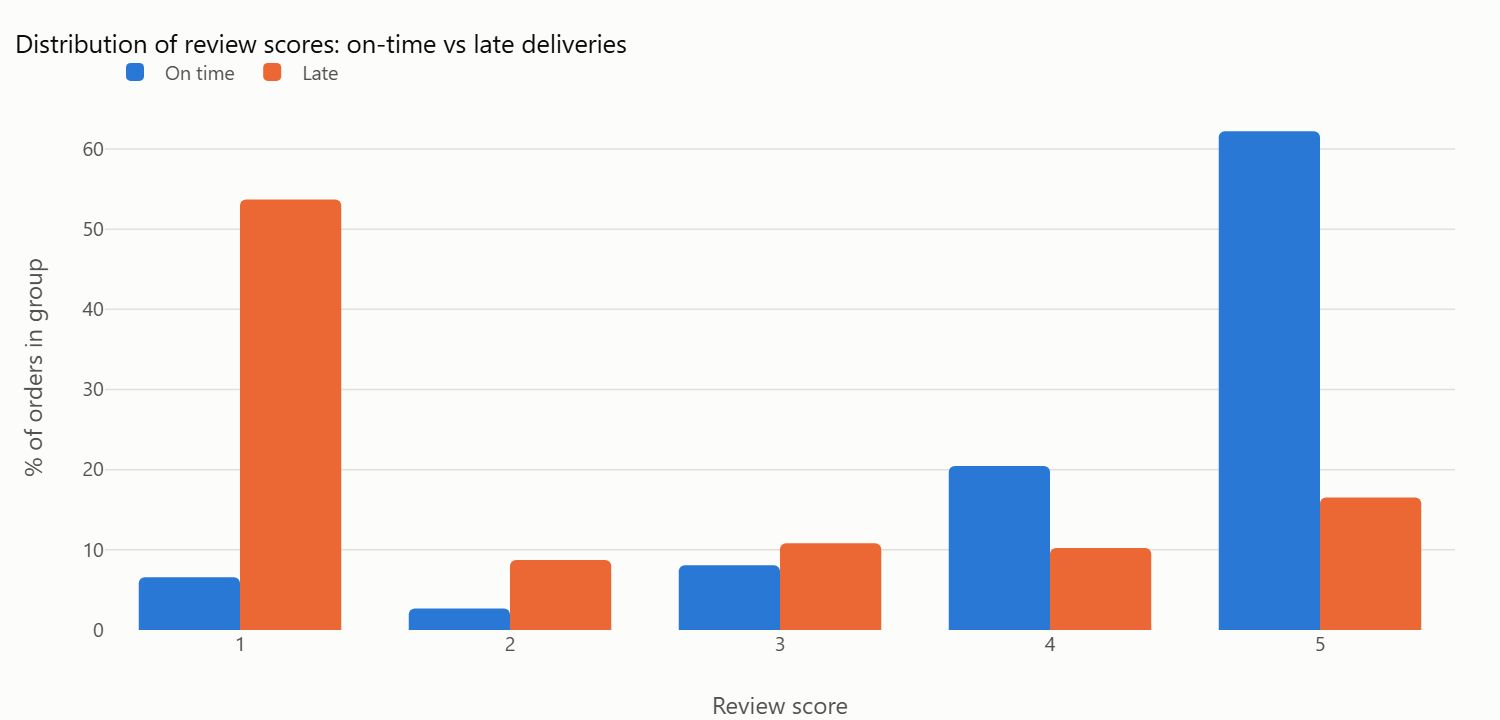

,orders,mean score,median score,% 1-star,Mann-Whitney p (late < on time)
On time,89443,4.29,5.00,6.58,NaN
Late,6381,2.27,1.00,53.69,0.00


In [12]:
d = query("""
    SELECT is_late, review_score, delivery_days - promised_days AS days_vs_promise
    FROM analytics.v_orders
    WHERE is_valid_sale AND is_late IS NOT NULL AND review_score IS NOT NULL
""")
late, on_time = d.loc[d["is_late"], "review_score"], d.loc[~d["is_late"], "review_score"]
mw = stats.mannwhitneyu(late, on_time, alternative="less")
rank_biserial = 1 - 2 * mw.statistic / (len(late) * len(on_time))
rho = stats.spearmanr(d["days_vs_promise"], d["review_score"])

dist = (d.assign(delivery=np.where(d["is_late"], "Late", "On time"), score=d["review_score"].round().astype(int))
         .groupby("delivery")["score"].value_counts(normalize=True).mul(100).unstack(0))
fig = go.Figure()
for name, color in [("On time", SERIES[0]), ("Late", SERIES[1])]:
    fig.add_bar(x=dist.index, y=dist[name], name=name, marker_color=color,
                hovertemplate=name + ": %{y:.1f}% of orders gave %{x}★<extra></extra>")
fig.update_layout(title="Distribution of review scores: on-time vs late deliveries", barmode="group",
                  xaxis=dict(title="Review score", dtick=1), yaxis=dict(title="% of orders in group"))
fig.show()

pd.DataFrame({
    "orders": [len(on_time), len(late)],
    "mean score": [on_time.mean(), late.mean()],
    "median score": [on_time.median(), late.median()],
    "% 1-star": [(on_time <= 1).mean() * 100, (late <= 1).mean() * 100],
}, index=["On time", "Late"]).join(pd.Series({"Late": mw.pvalue}, name="Mann-Whitney p (late < on time)"))

In [13]:
pd.Series({
    "Mann-Whitney U": mw.statistic,
    "p-value (one-sided)": mw.pvalue,
    "rank-biserial correlation": rank_biserial,
    "Spearman rho (days vs promise, score)": rho.statistic,
    "Spearman p-value": rho.pvalue,
}).to_frame("value").style.format("{:.4g}")

,value
Mann-Whitney U,1.033e+08
p-value (one-sided),0
rank-biserial correlation,0.638
"Spearman rho (days vs promise, score)",-0.1762
Spearman p-value,0


## 8. How do customers pay?

In [14]:
pay = query("""
    WITH b AS (
        SELECT width_bucket(revenue, ARRAY[50, 100, 200, 500, 1000]::numeric[]) AS bucket, main_payment_type, installments
        FROM analytics.v_orders
        WHERE is_valid_sale AND revenue > 0 AND main_payment_type IS NOT NULL)
    SELECT (ARRAY['< 50', '50-100', '100-200', '200-500', '500-1000', '>= 1000'])[bucket + 1] AS order_value_brl,
           count(*) AS orders,
           round(100.0 * avg((main_payment_type = 'credit_card')::int), 1) AS credit_card_pct,
           round(100.0 * avg((main_payment_type = 'boleto')::int), 1) AS boleto_pct,
           round(avg(installments) FILTER (WHERE main_payment_type = 'credit_card'), 2) AS avg_card_installments
    FROM b GROUP BY bucket ORDER BY bucket
""")
pay

,order_value_brl,orders,credit_card_pct,boleto_pct,avg_card_installments
0,< 50,29261,70.40,23.40,2.09
1,50-100,28192,75.10,20.00,3.17
2,100-200,25753,78.30,18.00,4.04
3,200-500,11389,81.10,16.10,5.43
4,500-1000,2675,82.00,15.60,7.08
5,>= 1000,928,82.10,15.70,7.86


## 9. Key findings

Generated from the results above. No number in this section is typed by hand.

In [15]:
aug = kpis.set_index("metric").loc["revenue"]
# p-values below double precision underflow to 0; report them as a bound instead.
p_text = "p < 1e-300" if mw.pvalue < 1e-300 else f"p = {mw.pvalue:.2g}"
low = geo[geo["orders"] >= 500].sort_values("late_delivery_rate", ascending=False).iloc[0]
growth_states = geo[geo["revenue_prev_6m"] >= 10_000].sort_values("growth_6m", ascending=False)
display(Markdown(f"""
1. **Growth then plateau.** Monthly revenue grew from {brl(monthly['revenue'].iloc[0])} in
   {monthly['month'].iloc[0]:%b %Y} to a peak of {brl(peak['revenue'])} in {peak['month']:%b %Y}. In 2018 the 3-month
   average levelled off between {brl(monthly.loc[monthly['month'] >= pd.Timestamp('2018-01-01').date(), 'revenue_3m_avg'].min())} and
   {brl(monthly.loc[monthly['month'] >= pd.Timestamp('2018-01-01').date(), 'revenue_3m_avg'].max())}. In the last complete month revenue
   changed {aug['change_pct']:+.2f}% vs the month before.
2. **Buying is a weekday habit.** {by_day.index[0]} is the busiest day and {by_day.index[-1]} the quietest
   ({by_day.iloc[0] / by_day.iloc[-1]:.2f}× difference). Hourly volume peaks at {int(by_hour.idxmax())}:00.
3. **Revenue is concentrated.** The top 10 categories generate {top10_share:.1%} of revenue, and
   {k80 / len(prod):.1%} of products generate 80% of it.
4. **Retention is the biggest gap.** Only {repeat_rate:.2%} of customers bought more than once, and they account for
   {repeat_revenue_share:.1%} of revenue. Month-1 retention never exceeds {retention.iloc[:, 0].max():.2f}% in any 2017 cohort.
   A repeat buyer is worth {clv_repeat / aov_one:.2f}× a one-time buyer in lifetime revenue.
5. **Late deliveries damage satisfaction.** Late orders average {late.mean():.2f}★ vs {on_time.mean():.2f}★ on time,
   and {(late <= 1).mean():.1%} of them get 1★ (vs {(on_time <= 1).mean():.1%}). The difference is statistically
   significant (Mann–Whitney {p_text}) with a large rank-biserial effect of {rank_biserial:.2f}. {low['state_name']} has
   the highest late-delivery rate among large states ({low['late_delivery_rate']:.1%}).
6. **Geography.** {geo.iloc[0]['state_name']} generates {geo.iloc[0]['revenue_share']:.1%} of revenue. Among states with meaningful
   volume, {growth_states.iloc[0]['state_name']} grew fastest over the last 6 months ({growth_states.iloc[0]['growth_6m']:+.1%}, from a
   small base of {brl(growth_states.iloc[0]['revenue_prev_6m'])}); {geo.iloc[0]['state_name']} grew {geo.iloc[0]['growth_6m']:+.1%}.
7. **Implications for the next phases:** delivery performance is a candidate churn feature; low repeat rates mean
   churn must be treated as a heavily imbalanced problem; and the Black-Friday spike must be handled explicitly by the
   forecasting and anomaly models.
"""))


1. **Growth then plateau.** Monthly revenue grew from R$ 244,959 in
   Feb 2017 to a peak of R$ 1,003,862 in Nov 2017. In 2018 the 3-month
   average levelled off between R$ 841,845 and
   R$ 989,172. In the last complete month revenue
   changed +1.71% vs the month before.
2. **Buying is a weekday habit.** Monday is the busiest day and Saturday the quietest
   (1.48× difference). Hourly volume peaks at 16:00.
3. **Revenue is concentrated.** The top 10 categories generate 62.4% of revenue, and
   25.9% of products generate 80% of it.
4. **Retention is the biggest gap.** Only 3.04% of customers bought more than once, and they account for
   5.6% of revenue. Month-1 retention never exceeds 0.71% in any 2017 cohort.
   A repeat buyer is worth 1.88× a one-time buyer in lifetime revenue.
5. **Late deliveries damage satisfaction.** Late orders average 2.27★ vs 4.29★ on time,
   and 53.7% of them get 1★ (vs 6.6%). The difference is statistically
   significant (Mann–Whitney p < 1e-300) with a large rank-biserial effect of 0.64. Maranhão has
   the highest late-delivery rate among large states (17.4%).
6. **Geography.** São Paulo generates 38.3% of revenue. Among states with meaningful
   volume, Piauí grew fastest over the last 6 months (+68.7%, from a
   small base of R$ 23,899); São Paulo grew +32.7%.
7. **Implications for the next phases:** delivery performance is a candidate churn feature; low repeat rates mean
   churn must be treated as a heavily imbalanced problem; and the Black-Friday spike must be handled explicitly by the
   forecasting and anomaly models.
